<div style="text-align:center">

# Proyecto 1  
## Clasificación de Riesgo Crediticio  

**Machine Learning**  
Universidad del Rosario

Vanessa Ochoa, Nilson Amaya, Juan Zamora

</div>


---

## Tabla de contenido

- [Introducción](#1-introducción)
- [Importación del dataset](#2-importación-del-dataset)
- [EDA](#3-análisis-exploratorio-de-datos-eda)
- [Modelos](#4-modelos)
- [Resultados](#5-resultados)
- [Conclusiones](#6-conclusiones)

<a id="1-introducción"></a>
## 1. Introducción

El riesgo crediticio es uno de los principales problemas que enfrentan las instituciones financieras, ya que implica la posibilidad de que una persona no cumpla con sus obligaciones de pago. Poder anticipar este tipo de situaciones es clave para reducir pérdidas y mejorar la toma de decisiones.

En este proyecto se utiliza el dataset **"Give Me Some Credit"** con el objetivo de predecir si una persona tendrá dificultades financieras en los próximos dos años. Este problema se aborda como una tarea de **clasificación binaria**, donde el modelo debe identificar si un cliente presenta riesgo de incumplimiento o no.

Para resolver este problema se desarrolla un flujo completo de **Machine Learning**, que incluye análisis exploratorio de datos (EDA), tratamiento de valores faltantes y outliers, implementación de modelos de clasificación como **k-NN** y **Regresión Logística**, así como la optimización de hiperparámetros mediante **Grid Search** y validación cruzada.

Finalmente, se comparan los modelos obtenidos para identificar cuál ofrece el mejor desempeño en la predicción del riesgo crediticio.

<a id="2-importación-del-dataset"></a>
## 2. Importación del dataset

Antes de cargar el dataset, se importan las librerías necesarias para realizar el proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
# Cargamos el dataset

train = pd.read_csv("../input/cs-training.csv")
test = pd.read_csv("../input/cs-test.csv")

# ver primeras filas
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

### 2.1 Descripción de las variables

- **SeriousDlqin2yrs:** Indica si la persona ha tenido una morosidad grave, es decir, un atraso de 90 días o más en el pago de sus obligaciones durante los últimos dos años. Es la variable objetivo del modelo.

- **RevolvingUtilizationOfUnsecuredLines:** Proporción del saldo utilizado en tarjetas de crédito y líneas de crédito personales respecto al límite total disponible.

- **age:** Edad del solicitante del crédito expresada en años.

- **NumberOfTime30-59DaysPastDueNotWorse:** Número de veces que el prestatario ha tenido retrasos en sus pagos entre 30 y 59 días durante los últimos dos años.

- **DebtRatio:** Relación entre las obligaciones financieras mensuales (deudas, manutención, gastos) y el ingreso bruto mensual del prestatario.

- **MonthlyIncome:** Ingreso mensual reportado por el prestatario.

- **NumberOfOpenCreditLinesAndLoans:** Número total de préstamos y líneas de crédito abiertas, como tarjetas de crédito, préstamos de auto o hipotecas.

- **NumberOfTimes90DaysLate:** Número de veces que el prestatario ha tenido retrasos en pagos de 90 días o más.

- **NumberRealEstateLoansOrLines:** Número de préstamos relacionados con bienes raíces, incluyendo hipotecas y líneas de crédito sobre vivienda.

- **NumberOfTime60-89DaysPastDueNotWorse:** Número de veces que el prestatario ha tenido retrasos en pagos entre 60 y 89 días en los últimos dos años.

- **NumberOfDependents:** Número de personas dependientes económicamente del prestatario, como hijos o cónyuge.

In [11]:
train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


<a id="3-análisis-exploratorio-de-datos-eda"></a>
## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Identificación y tratamiento de datos faltantes e imputación lógica

Primero identificamos el porcentaje de datos faltantes por variable y, con base en el contexto, aplicamos una imputación lógica:




In [4]:
faltantes = train.isnull().sum()
porcentaje = (faltantes / len(train)) * 100
tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje %': porcentaje.round(2)
})
print(tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0])

                    Valores faltantes  Porcentaje %
MonthlyIncome                   29731         19.82
NumberOfDependents               3924          2.62


Con base en la revisión de valores faltantes, se identificó que las variables MonthlyIncome y NumberOfDependents presentan datos ausentes. Dado que ambas corresponden a variables numéricas, se optó por realizar una imputación utilizando la mediana de cada variable. La mediana se define como el valor central de la distribución cuando los datos se ordenan de menor a mayor. A diferencia de la media, la mediana es menos sensible a la presencia de outliers que en variables financieras es muy común que pase. Por esta razón, la mediana permite imputar los valores faltantes con un valor representativo de la distribución sin distorsionar significativamente su forma. De esta manera, se conserva la estructura general de los datos y se evita introducir sesgos que podrían afectar el entrenamiento del modelo.

In [6]:
# Imputación lógica
train['MonthlyIncome'] = train['MonthlyIncome'].fillna(train['MonthlyIncome'].median())
train['NumberOfDependents'] = train['NumberOfDependents'].fillna(train['NumberOfDependents'].median())

# Verificar que ya no hay faltantes
print("Faltantes después de imputación:")
print(train.isnull().sum().sum())


Faltantes después de imputación:
0


### 3.2 Análisis de distribuciones y detección de outliers

Analizamos la forma de las distribuciones con histogramas y boxplots. Para detectar valores atípicos extremos usamos el criterio del **IQR (rango intercuartílico)** y realizamos winsorización suave (capado por percentiles) en variables con colas muy largas.


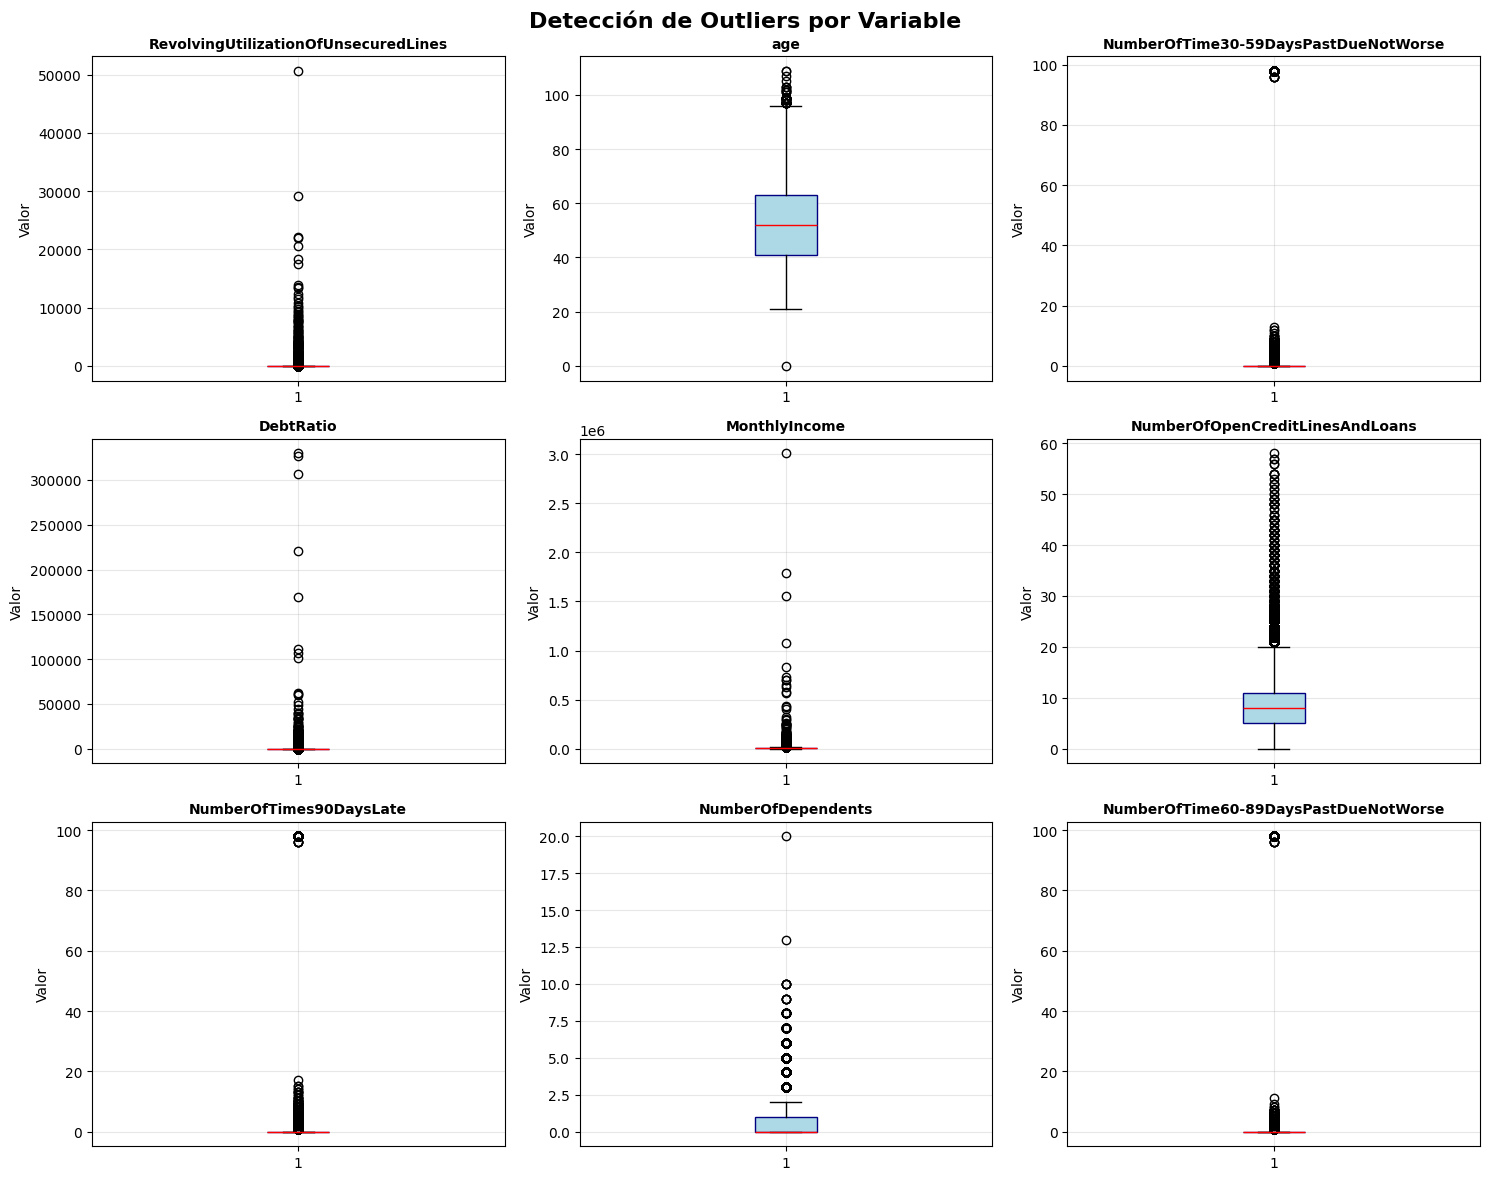

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columnas = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberOfDependents',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for i, col in enumerate(columnas):
    axes[i].boxplot(train[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red'))
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(alpha=0.3)

fig.suptitle('Detección de Outliers por Variable',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

A partir de los boxplots se observa que varias variables presentan valores atípicos, especialmente en RevolvingUtilizationOfUnsecuredLines, DebtRatio y MonthlyIncome, donde hay una gran dispersión y algunos valores extremadamente altos. En las variables relacionadas con retrasos en pagos, la mayoría de los valores se concentran cerca de cero, pero aparecen algunos casos con muchos incumplimientos.

In [ ]:
# Caps de valores imposibles o extremos
# RevolvingUtilization y DebtRatio deben estar entre 0 y 1
train['RevolvingUtilizationOfUnsecuredLines'] = train['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
train['DebtRatio'] = train['DebtRatio'].clip(0, 1)

# Valores 96, 97, 98 en variables de retrasos son códigos de error
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    train[col] = train[col].replace([96, 97, 98], 0)

# Age mínima razonable = 18
train['age'] = train['age'].clip(18, 100)

# MonthlyIncome cap en percentil 99
cap_income = train['MonthlyIncome'].quantile(0.99)
train['MonthlyIncome'] = train['MonthlyIncome'].clip(0, cap_income)

print("Outliers tratados correctamente")
print("\nEstadísticas después del tratamiento:")
train.describe().round(2)

NameError: name 'df' is not defined

### 3.3 Análisis de correlación y selección de características justificadas

Calculamos la correlación de Pearson entre variables numéricas y observamos su relación con la variable objetivo (**SeriousDlqin2yrs**). La selección inicial de características se basa en:

1. **Relevancia estadística** (magnitud de correlación con el objetivo).
2. **No redundancia** (evitar pares altamente correlacionados entre sí).
3. **Interpretabilidad de negocio** (variables de mora, utilización de crédito e ingresos son explicativas del riesgo).


In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

corr_target = corr['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values(key=lambda x: x.abs(), ascending=False)
corr_target.head(10)


In [ ]:
# Selección justificada de características
selected_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

X = df[selected_features]
y = df['SeriousDlqin2yrs']

print('Variables seleccionadas para modelado:')
print(selected_features)
print('\nDimensiones de X e y:', X.shape, y.shape)


<a id="4-modelos"></a>
## 4. Implementación de Modelos

<a id="5-resultados"></a>
## 5. Optimización de Hiperparámetros y Validación

<a id="6-conclusiones"></a>
## 6. Métricas de Evaluación y Decisión